In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import talib
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import os
import random

from sklearn.preprocessing import MinMaxScaler, StandardScaler

from IPython.display import clear_output

%matplotlib inline

pd.set_option('display.max_columns', None)

In [2]:
import warnings
warnings.filterwarnings('ignore')

# Загрузка данных и подготовка

In [3]:
# Загрузим из файла
eth_df = pd.read_csv('..\data\ETHUSDT_final_26_01_2026.csv').rename(columns={'timestamp': 'Datetime'}).set_index('Datetime')
eth_df.index = pd.to_datetime(eth_df.index)
eth_df 

,Open,High,Low,Close,Volume
Datetime,,,,,
2024-01-01 00:15:00,2296.56,2296.90,2288.80,2290.90,1109
2024-01-01 00:30:00,2290.90,2294.40,2288.51,2293.19,953
2024-01-01 00:45:00,2293.19,2297.16,2292.30,2295.61,592
2024-01-01 01:00:00,2295.61,2297.20,2291.91,2296.40,1424
2024-01-01 01:15:00,2296.40,2300.17,2296.50,2298.95,496
...,...,...,...,...,...
2026-01-25 22:45:00,2802.87,2807.22,2790.56,2807.22,832
2026-01-25 23:00:00,2807.22,2809.64,2787.21,2801.06,2717
2026-01-25 23:15:00,2801.06,2813.23,2792.41,2805.38,1664


In [4]:
# Проверим на пропуски
eth_df.isnull().sum()

Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64

Пропусков нет

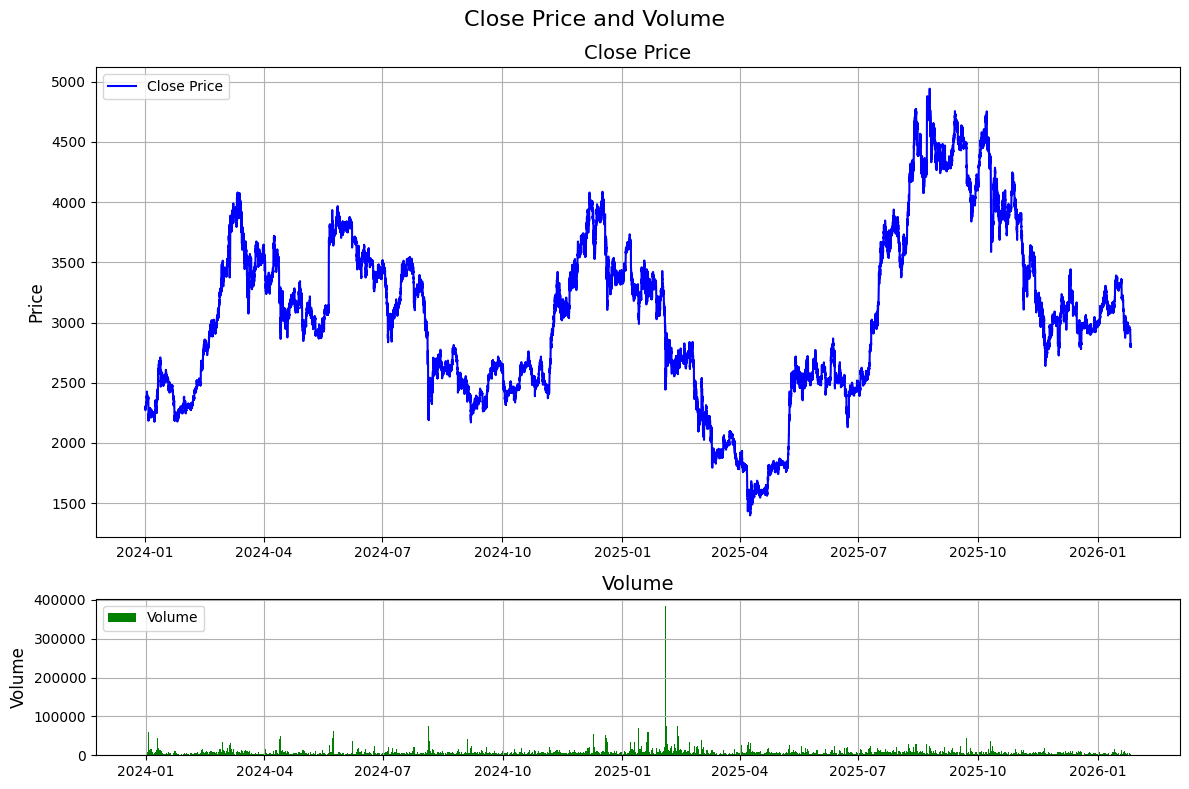

In [5]:
fig, (ax1, ax2) = plt.subplots(
    2, 1,  # 2 строки, 1 столбец
    figsize=(12, 8),
    gridspec_kw={'height_ratios': [3, 1]}
)

# График Close (цена)
ax1.plot(eth_df.index, eth_df['Close'], label='Close Price', color='blue')
ax1.set_title('Close Price', fontsize=14)
ax1.set_ylabel('Price', fontsize=12)
ax1.legend(loc='upper left')
ax1.grid(True)

# График Volume (объем)
ax2.bar(eth_df.index, eth_df['Volume'], label='Volume', color='green')
ax2.set_title('Volume', fontsize=14)
ax2.set_ylabel('Volume', fontsize=12)
ax2.legend(loc='upper left')
ax2.grid(True)

# Настройка общего заголовка
plt.suptitle('Close Price and Volume', fontsize=16)

# Отображение графиков
plt.tight_layout()
plt.show()

In [6]:
eth_df.describe()

,Open,High,Low,Close,Volume
count,72575.000000,72575.000000,72575.000000,72575.000000,72575.000000
mean,3058.111722,3065.216643,3050.650204,3058.118898,1860.948426
std,700.287370,701.662425,698.797369,700.282235,2965.609885
min,1397.840000,1422.690000,1384.840000,1397.840000,36.000000
25%,2528.965000,2534.560000,2523.445000,2528.985000,739.000000
50%,3056.150000,3064.310000,3047.170000,3056.150000,1284.000000
75%,3512.530000,3519.865000,3504.900000,3512.530000,2197.000000
max,4942.630000,4956.720000,4934.540000,4942.630000,383820.000000


Есть большие выбросы в объеме торгов. Нужно замениить их на значение, ближе к нормальному, но чтобы они оставались максимальными в датасете

In [ ]:
# Вычисляем порог: 99.9-й квантиль
upper_limit = int(eth_df['Volume'].quantile(0.999))
print(f"99.9-й процентиль (порог): {upper_limit:.2f}")

# Считаем количество выбросов
outliers_count = (eth_df['Volume'] > upper_limit).sum()
outliers_percent = (outliers_count / len(eth_df)) * 100

print(f"Найдено выбросов: {outliers_count} ({outliers_percent:.3f}% от всех данных)")
print(f"Порог обрезки (99.9-й процентиль): {upper_limit:.2f}")

# Заменяем все значения, превышающие порог, на этот порог
eth_df['Volume'] = eth_df['Volume'].clip(upper=upper_limit)

# Проверка результата
print(f"Новый максимум: {eth_df['Volume'].max()}")
print(f"99.9-й процентиль (порог): {upper_limit}")


99.9-й процентиль (порог): 25613.00
Найдено выбросов: 73 (0.101% от всех данных)
Порог обрезки (99.9-й процентиль): 25613.00
Новый максимум: 25613
99.9-й процентиль (порог): 25613


In [8]:
eth_df.describe()

,Open,High,Low,Close,Volume
count,72575.000000,72575.000000,72575.000000,72575.000000,72575.000000
mean,3058.111722,3065.216643,3050.650204,3058.118898,1837.077286
std,700.287370,701.662425,698.797369,700.282235,2035.833120
min,1397.840000,1422.690000,1384.840000,1397.840000,36.000000
25%,2528.965000,2534.560000,2523.445000,2528.985000,739.000000
50%,3056.150000,3064.310000,3047.170000,3056.150000,1284.000000
75%,3512.530000,3519.865000,3504.900000,3512.530000,2197.000000
max,4942.630000,4956.720000,4934.540000,4942.630000,25613.000000


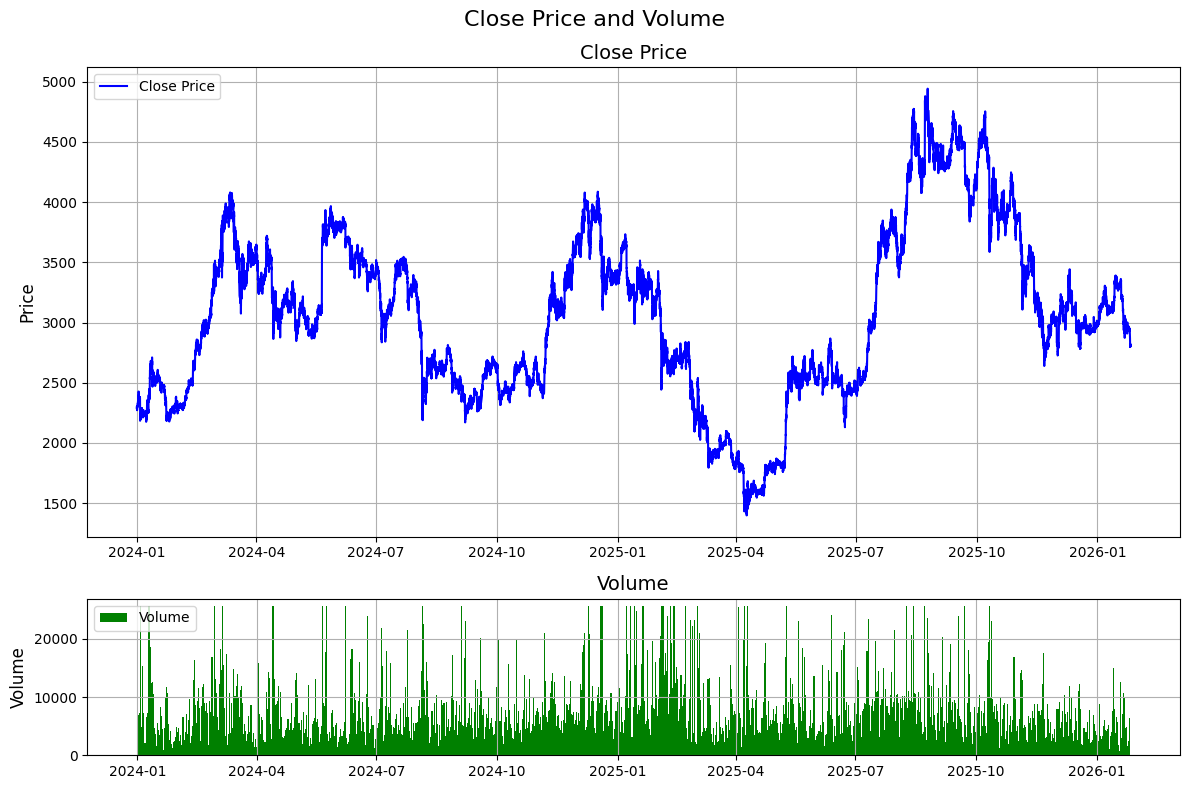

In [23]:
fig, (ax1, ax2) = plt.subplots(
    2, 1,  # 2 строки, 1 столбец
    figsize=(12, 8),
    gridspec_kw={'height_ratios': [3, 1]}
)

# График Close (цена)
ax1.plot(eth_df.index, eth_df['Close'], label='Close Price', color='blue')
ax1.set_title('Close Price', fontsize=14)
ax1.set_ylabel('Price', fontsize=12)
ax1.legend(loc='upper left')
ax1.grid(True)

# График Volume (объем)
ax2.bar(eth_df.index, eth_df['Volume'], label='Volume', color='green')
ax2.set_title('Volume', fontsize=14)
ax2.set_ylabel('Volume', fontsize=12)
ax2.legend(loc='upper left')
ax2.grid(True)

# Настройка общего заголовка
plt.suptitle('Close Price and Volume', fontsize=16)

# Отображение графиков
plt.tight_layout()
plt.show()

Теперь Объем в данных выглядит лучше

# Добавление индикаторов

In [9]:
def fill_missing_values(data):
    """
    Функция заполняет пропущенные значения в DataFrame предыдущими значениями 
    и удаляет дубликаты по индексу.
    """
    df = data.copy()

    # Проверка и удаление дубликатов по индексу
    if df.index.duplicated().any():
        print("Обнаружены дубликаты по индексу. Они будут удалены.")
        df = df[~df.index.duplicated(keep='first')]
    else:
        print("Дубликатов не обнаружено.")

    # Проверка на наличие пропущенных значений и нулевых значений
    if df.isnull().any().any() or (df == 0).any().any():
        print("Обнаружены пропущенные или нулевые значения. Выполняется заполнение предыдущими значениями...")

        # Заменяем нули на NaN, чтобы их можно было заполнить
        df.replace(0, np.nan, inplace=True)
        
        # Заполняем пропущенные значения предыдущими
        df = df.fillna(method='ffill')
        
        # Если в начале есть NaN, заполняем их последующими значениями
        df = df.fillna(method='bfill')
    else:
        print("Пропущенные значения отсутствуют.")

    return df

In [10]:
# Функция для добавления лагов

def add_lags(data, columns, lags):
    """Функция для добавления лагов

    Args:
        data (pd.Dataframe): pandas Dataframe с данными по активу
        columns (List): список колонорк для расчета лагов
        lags (List): список шагов назад для расчета лагов
    """
    df = data.copy()

    for lag in lags: # Добавляем лаги по шагам назад из lags
        for column in columns:
            new_col_name = f'{column}_lag_{lag}'
            df[new_col_name] = df[column].shift(lag)
    
    return df

In [11]:
# Функция для добавления индикаторов

def add_indicators(data, columns, windows_SMA, windows_RSI):
    """Функция для добавления индикаторов SMA и RSI

    Args:
        data (pd.Dataframe): pandas Dataframe с данными по активу
        columns (List): список колонорк для расчета индикаторов
        windows_SMA (List): список окон для расчета MA
        windows_RSI (List): список окон для расчета RSI
    """
    df = data.copy()

    for window in windows_SMA: # Расчитываем и добавляем SMA по указанным колонкам
        for column in columns:
            new_col_name = f'{column}_SMA_{window}'
            df[new_col_name] = df[column].rolling(window).mean()

    for window in windows_RSI: # Расчитываем и добавляем RSI по указанным колонкам
        for column in columns:
            new_col_name = f'{column}_RSI_{window}'
            df[new_col_name] = talib.RSI(df[column], timeperiod=window)
    
    return df

In [12]:
# Функция для добавления статистик

def add_stats_features(data, columns, windows):
    """Функция для добавления статистик, min, max, std за периоды windows

    Args:
        data (pd.Dataframe): pandas Dataframe с данными по активу
        columns (List): список колонорк для расчета статистик
        windows (List): список окон для расчета статистик
    """   
    df = data.copy()

    for column in columns:
        for window in windows:
            # Скользящее среднее
            df[f'{column}_mean_{window}'] = df[column].rolling(window=window).mean()
            
            # Скользящая медиана
            df[f'{column}_median_{window}'] = df[column].rolling(window=window).median()
            
            # Скользящий минимум
            df[f'{column}_min_{window}'] = df[column].rolling(window=window).min()
            
            # Скользящий максимум
            df[f'{column}_max_{window}'] = df[column].rolling(window=window).max()
            
            # Скользящее стандартное отклонение
            df[f'{column}_std_{window}'] = df[column].rolling(window=window).std()
            
            # Скользящий размах (макс - мин)
            df[f'{column}_range_{window}'] = df[f'{column}_max_{window}'] - df[f'{column}_min_{window}']

    return df

In [13]:
# Функция для добавления разницы между higt и low

def add_hight_low_dif(data):
    df = data.copy()
    df['High-Low'] = df['High'] - df['Low']
    return df

In [14]:
# Функция для добавления трендовых фичей

def add_trend_feat(data, columns, windows):
    """Функция для трендовых фичей

    Args:
        data (pd.Dataframe): pandas Dataframe с данными по активу
        columns (List): список колонорк трендовых фичей
        windows (List): список окон трендовых фичей
    """   
    df = data.copy()
    for column in columns:
        for window in windows:
            # Отношение текущего значения к предыдущему (лаг = 1)
            df[f'{column}_ratio_1'] = df[column] / df[column].shift(1)
            
            # Логарифмическое изменение (логарифм отношения текущего значения к предыдущему)
            df[f'{column}_log_diff_1'] = np.log(df[column] / df[column].shift(1))
            
            # Momentum (разница между текущим значением и значением N периодов назад)
            df[f'{column}_momentum_{window}'] = df[column] - df[column].shift(window)
            
            # Rate of Change (ROC): процентное изменение за N периодов
            df[f'{column}_roc_{window}'] = (df[column] - df[column].shift(window)) / df[column].shift(window) * 100
    
    return df    

In [17]:
# Функция для добавления номеров месяцев, дней, часов

def add_datetime_features(data, add_month=True, add_weekday=True, add_hour=True):
    """Функция добавляет в DataFrame столбцы с номером месяца, дня недели и часа из индекса Datetime.
    
    Args:
    df (pd.DataFrame): DataFrame с индексом типа Datetime.
    add_month (bool): Добавлять ли столбец с номером месяца (1-12).
    add_weekday (bool): Добавлять ли столбец с номером дня недели (0 - понедельник, 6 - воскресенье).
    add_hour (bool): Добавлять ли столбец с номером часа (0-23).
    """
    df = data.copy()
    
    # Добавляем столбцы по выбору
    if add_month:
        df['Month'] = df.index.month
    if add_weekday:
        df['Weekday'] = df.index.weekday
    if add_hour:
        df['Hour'] = df.index.hour
    
    return df

In [18]:
def prepare_date(data, 
                 lags, 
                 windows_SMA, 
                 windows_RSI, 
                 windows_stats, 
                 windows_trend, 
                 add_month=True, 
                 add_weekday=True, 
                 add_hour=True):
    """
    Функция для добавления фичей и нормализации

    Args:
        data (pd.DataFrame): DataFrame с индексом типа Datetime.
        windows_SMA (List): список окон для индикатора SMA.
        windows_RSI (List): список окон для индикатора RSI.
        windows_stats (List): список окон для статистических фичей.
        windows_trend (List): список окон для трендовых фичей.
        add_month (bool): Добавлять ли столбец с номером месяца (1-12).
        add_weekday (bool): Добавлять ли столбец с номером дня недели (0 - понедельник, 6 - воскресенье).
        add_hour (bool): Добавлять ли столбец с номером часа (0-23).
    """

    df = data.copy()
    columns = df.columns

    df = fill_missing_values(df)
    df = add_lags(df, columns=columns, lags=lags)
    df = add_indicators(df, columns=['Close'], windows_SMA=windows_SMA, windows_RSI=windows_RSI)
    df = add_stats_features(df, columns=['Close'], windows=windows_stats)
    df = add_hight_low_dif(df)
    df = add_trend_feat(df, columns=['Close'], windows=windows_trend)
    df = add_datetime_features(df, add_month=add_month, add_weekday=add_weekday, add_hour=add_hour)
    df = df.dropna()

    return df

In [19]:
eth_df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 72575 entries, 2024-01-01 00:15:00 to 2026-01-25 23:45:00
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Open    72575 non-null  float64
 1   High    72575 non-null  float64
 2   Low     72575 non-null  float64
 3   Close   72575 non-null  float64
 4   Volume  72575 non-null  int64  
dtypes: float64(4), int64(1)
memory usage: 3.3 MB


In [20]:
window_lag = [3, 9, 15, 30]
window_SMA = [6, 9, 30, 50]
window_RSI = [4, 9, 20]
windows_stats = [3, 10, 30, 50]
windows_trend = [3, 10, 30, 50]

In [21]:
eth_df_features = prepare_date(eth_df, lags=window_lag, windows_SMA=window_SMA, 
                               windows_RSI=window_RSI, windows_stats=windows_stats, 
                               windows_trend=windows_trend)

Дубликатов не обнаружено.
Пропущенные значения отсутствуют.


In [22]:
eth_df_features

,Open,High,Low,Close,Volume,Open_lag_3,High_lag_3,Low_lag_3,Close_lag_3,Volume_lag_3,Open_lag_9,High_lag_9,Low_lag_9,Close_lag_9,Volume_lag_9,Open_lag_15,High_lag_15,Low_lag_15,Close_lag_15,Volume_lag_15,Open_lag_30,High_lag_30,Low_lag_30,Close_lag_30,Volume_lag_30,Close_SMA_6,Close_SMA_9,Close_SMA_30,Close_SMA_50,Close_RSI_4,Close_RSI_9,Close_RSI_20,Close_mean_3,Close_median_3,Close_min_3,Close_max_3,Close_std_3,Close_range_3,Close_mean_10,Close_median_10,Close_min_10,Close_max_10,Close_std_10,Close_range_10,Close_mean_30,Close_median_30,Close_min_30,Close_max_30,Close_std_30,Close_range_30,Close_mean_50,Close_median_50,Close_min_50,Close_max_50,Close_std_50,Close_range_50,High-Low,Close_ratio_1,Close_log_diff_1,Close_momentum_3,Close_roc_3,Close_momentum_10,Close_roc_10,Close_momentum_30,Close_roc_30,Close_momentum_50,Close_roc_50,Month,Weekday,Hour
Datetime,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2024-01-01 12:45:00,2306.29,2306.27,2299.20,2299.49,493,2304.50,2306.54,2300.81,2300.90,259.0,2299.20,2300.98,2299.20,2300.90,359.0,2287.07,2291.40,2287.00,2289.89,896.0,2283.00,2283.22,2277.11,2278.59,433.0,2302.315000,2302.423333,2291.412667,2289.9810,39.303868,52.062178,55.042475,2302.960000,2303.10,2299.49,2306.29,3.402161,6.80,2302.271,2302.260,2299.49,2306.29,2.151457,6.80,2291.412667,2289.845,2274.80,2306.29,10.151109,31.49,2289.9810,2289.845,2271.77,2306.29,10.456837,34.52,7.07,0.997052,-0.002953,-1.41,-0.061280,0.29,0.012613,20.90,0.917234,8.59,0.374962,1,0,12
2024-01-01 13:00:00,2299.49,2303.59,2298.18,2303.30,355,2300.90,2303.20,2300.01,2303.10,197.0,2300.90,2303.30,2300.70,2302.29,301.0,2289.89,2292.08,2288.00,2289.80,450.0,2278.59,2280.19,2276.29,2279.10,293.0,2302.930000,2302.535556,2292.219333,2290.1832,54.480373,58.599008,58.119619,2303.026667,2303.30,2299.49,2306.29,3.408230,6.80,2302.511,2302.695,2299.49,2306.29,2.115081,6.80,2292.219333,2293.395,2274.80,2306.29,10.100343,31.49,2290.1832,2289.845,2271.77,2306.29,10.616679,34.52,5.41,1.001657,0.001656,0.20,0.008684,2.40,0.104307,24.20,1.061823,10.11,0.440871,1,0,13
2024-01-01 13:15:00,2303.30,2306.79,2303.30,2306.49,238,2303.10,2307.20,2302.27,2306.29,536.0,2302.29,2305.24,2301.81,2303.40,534.0,2289.80,2298.06,2289.80,2296.90,861.0,2279.10,2279.20,2272.60,2275.80,323.0,2303.261667,2302.878889,2293.242333,2290.4008,64.413759,63.311370,60.502265,2303.093333,2303.30,2299.49,2306.49,3.504573,7.00,2302.931,2303.200,2299.49,2306.49,2.455870,7.00,2293.242333,2298.050,2274.80,2306.49,9.932795,31.69,2290.4008,2289.845,2271.77,2306.49,10.839341,34.72,3.49,1.001385,0.001384,0.20,0.008672,4.20,0.182427,30.69,1.348537,10.88,0.473948,1,0,13
2024-01-01 13:30:00,2306.49,2307.48,2303.80,2307.48,258,2306.29,2306.27,2299.20,2299.49,493.0,2303.40,2304.20,2300.41,2302.23,272.0,2296.90,2299.81,2296.81,2299.79,386.0,2275.80,2278.30,2274.20,2274.80,573.0,2304.358333,2303.462222,2294.331667,2290.6224,67.361019,64.713641,61.222949,2305.756667,2306.49,2303.30,2307.48,2.184361,4.18,2303.339,2303.200,2299.49,2307.48,2.849766,7.99,2294.331667,2299.345,2276.09,2307.48,9.627805,31.39,2290.6224,2289.845,2271.77,2307.48,11.075186,35.71,3.68,1.000429,0.000429,7.99,0.347468,4.08,0.177129,32.68,1.436610,11.08,0.482494,1,0,13
2024-01-01 13:45:00,2307.48,2308.17,2304.20,2304.20,914,2299.49,2303.59,2298.18,2303.30,355.0,2302.23,2303.10,2299.14,2299.61,228.0,2299.79,2302.39,2299.70,2300.40,430.0,2274.80,2280.32,2274.21,2276.09,742.0,2304.541667,2303.972222,2295.268667,2290.7274,49.317696,56.644143,57.560179,2306.056667,2306.49,2304.20,2307.48,1.682389,3.28,2303.536,2303.750,2299.49,2307.48,2.832624,7.99,2295.268667,2299.550,2281.01,2307.48,9.147132,26.47,2290.7274,2289.845,2271.77,2307.48,11.180138,35.71,3.97,0.998579,-0.001422,0.90,0.039074,1.97,0.085569,28.11,1.235013,5.25,0.228365,1,0,13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,

In [31]:
eth_df_features.to_csv("../data/eth_df_features.csv", index=True)
